# Модель експоненційного зростання населення

**Формула:** $y_t = (1 + a)y_{t-1}$, де:
*   $y_t$ — населення в момент часу $t$;
*   $a$ — коефіцієнт приросту.

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
import copy

In [2]:
def simulate_exponential_growth(n0, a, years):
    
    population = [n0]
    
    for t in range(years):
        current_pop = population[-1]
        
        next_pop = (1 + a) * current_pop
        
        population.append(next_pop)
        
    return population

In [3]:
# --- ЕТАП МОДЕЛЮВАННЯ ДЛЯ РІЗНИХ НАБОРІВ ДАНИХ ---

# Загальні налаштування часу
years = 20

# Початково: 100 осіб, приріст 5% (0.05)
data1 = simulate_exponential_growth(n0=100, a=0.05, years=years)

# Початково: 50 осіб, але високий приріст 15% (0.15)
data2 = simulate_exponential_growth(n0=50, a=0.15, years=years)

# Початково: 500 осіб, від'ємний приріст -5% (-0.05)
data3 = simulate_exponential_growth(n0=500, a=-0.05, years=years)

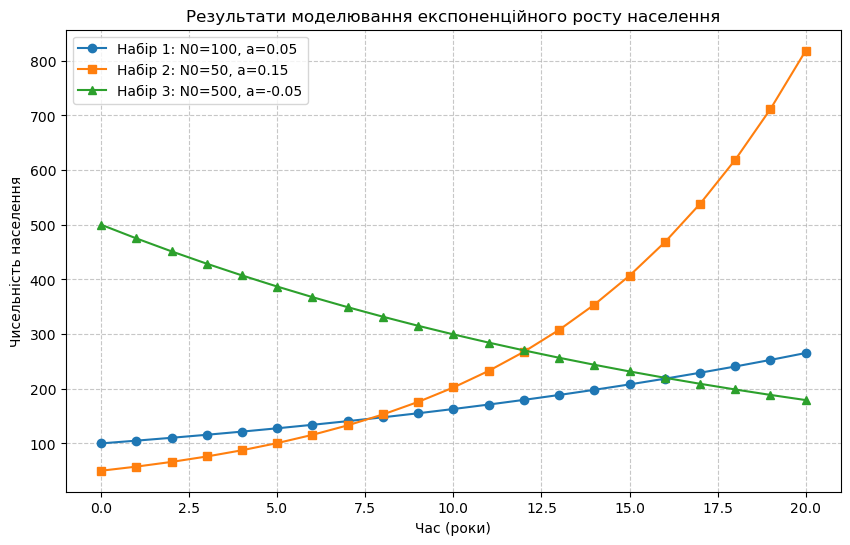

In [4]:
# --- ВІЗУАЛІЗАЦІЯ РЕЗУЛЬТАТІВ ---

plt.figure(figsize=(10, 6))

time_axis = range(years + 1)

plt.plot(time_axis, data1, marker='o', label="Набір 1: N0=100, a=0.05")
plt.plot(time_axis, data2, marker='s', label="Набір 2: N0=50, a=0.15")
plt.plot(time_axis, data3, marker='^', label="Набір 3: N0=500, a=-0.05")

plt.title("Результати моделювання експоненційного росту населення")
plt.xlabel("Час (роки)")
plt.ylabel("Чисельність населення")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

# Модель гонки озброєнь Річардсона

Модель описується системою диференційних рівнянь:

$$
\begin{cases}
\frac{dx}{dt} = ay - mx + r \\
\frac{dy}{dt} = bx - ny + s
\end{cases}
$$

Де:
*   $x, y$ — витрати на озброєння країн X та Y.
*   $a, b$ — коефіцієнти "страху/оборони" (реакція на озброєння сусіда).
*   $m, n$ — коефіцієнти "втоми/економіки" (гальмування через витрати).
*   $r, s$ — коефіцієнти "претензій/образ" (постійні причини конфлікту).

**Умова стійкості:**
*   Якщо $mn - ab > 0$ — система **стійка**.
*   Якщо $mn - ab < 0$ — система **нестійка** (нескінченна гонка озброєнь).

In [5]:
def richardson_model(params, x0, y0, years, dt=0.1):
    steps = int(years / dt)
    t_values = np.linspace(0, years, steps)
    
    x = np.zeros(steps)
    y = np.zeros(steps)
    
    x[0] = x0
    y[0] = y0
    
    a, b = params['a'], params['b']
    m, n = params['m'], params['n']
    g, h = params['g'], params['h']
    
    for i in range(1, steps):
        # Попередні значення
        prev_x = x[i-1]
        prev_y = y[i-1]
        
        # Обчислення похідних (швидкості зміни)
        dxdt = a * prev_y - m * prev_x + g
        dydt = b * prev_x - n * prev_y + h
        
        # Оновлення значень (Метод Ейлера)
        x[i] = prev_x + dxdt * dt
        y[i] = prev_y + dydt * dt
        
    return t_values, x, y

def check_stability(params):
    """Перевірка умови стійкості: mn - ab > 0"""
    val = params['m'] * params['n'] - params['a'] * params['b']
    status = "СТІЙКА (Рівновага)" if val > 0 else "НЕСТІЙКА (Ескалація)"
    return val, status

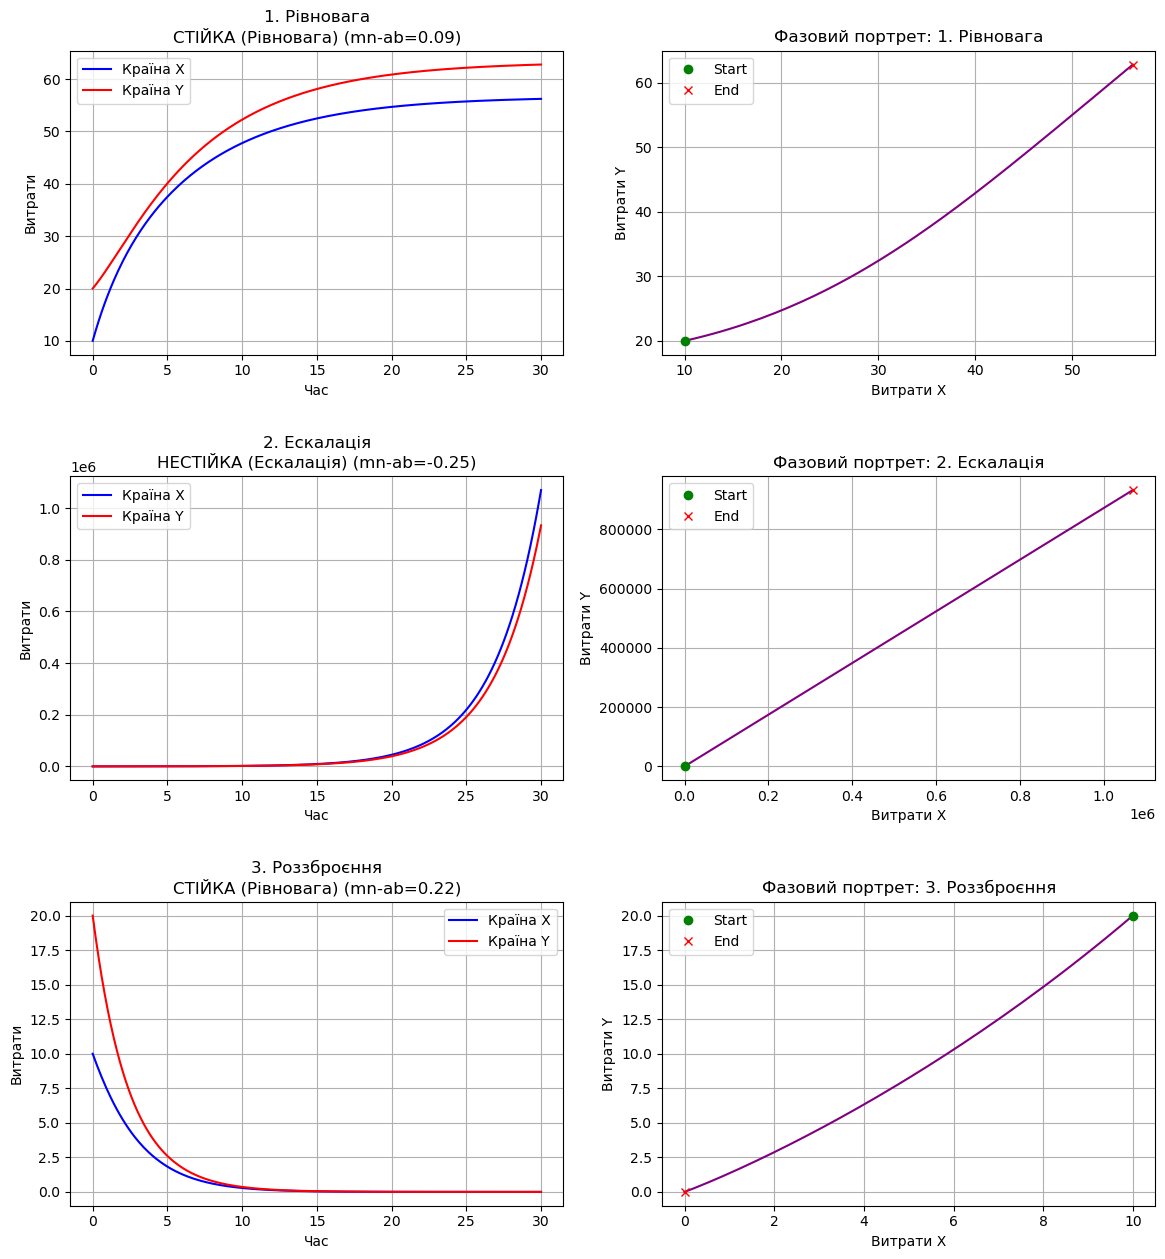

In [6]:

# --- НАБОРИ ДАНИХ ДЛЯ ЕКСПЕРИМЕНТІВ ---

# Сценарій 1: СТІЙКИЙ МИР (Стримування працює)
# Втома економіки (m, n) вища за страх (a, b)
params_1 = {'a': 0.2, 'm': 0.4, 'g': 10,
            'b': 0.25,'n': 0.35,'h': 8}

# Сценарій 2: НЕСТІЙКА ГОНКА (Ескалація конфлікту)
# Страх (a, b) переважає економіку (m, n)
params_2 = {'a': 0.6, 'm': 0.2, 'g': 20,
            'b': 0.5, 'n': 0.25,'h': 18}

# Сценарій 3: ВЗАЄМНЕ РОЗЗБРОЄННЯ (Дружні стосунки)
# Негативні g та h (співпраця), сильна економія
params_3 = {'a': 0.1, 'm': 0.5, 'g': 0,
            'b': 0.08,'n': 0.45,'h': 0}

scenarios = [
    ("1. Рівновага", params_1),
    ("2. Ескалація", params_2),
    ("3. Роззброєння", params_3)
]

# --- ВІЗУАЛІЗАЦІЯ ---
fig, axes = plt.subplots(3, 2, figsize=(14, 15))
plt.subplots_adjust(hspace=0.4)

for i, (name, p) in enumerate(scenarios):
    # Запуск моделі
    t, x, y = richardson_model(p, x0=10, y0=20, years=30)
    
    # Аналіз стійкості
    stab_val, stab_str = check_stability(p)
    title_text = f"{name}\n{stab_str} (mn-ab={stab_val:.2f})"
    
    # Графік 1: Часовий ряд (X(t), Y(t))
    ax_time = axes[i, 0]
    ax_time.plot(t, x, label='Країна X', color='blue')
    ax_time.plot(t, y, label='Країна Y', color='red')
    ax_time.set_title(title_text)
    ax_time.set_xlabel('Час')
    ax_time.set_ylabel('Витрати')
    ax_time.legend()
    ax_time.grid(True)
    
    # Графік 2: Фазовий портрет (Y від X)
    ax_phase = axes[i, 1]
    ax_phase.plot(x, y, color='purple')
    ax_phase.set_title(f"Фазовий портрет: {name}")
    ax_phase.set_xlabel('Витрати X')
    ax_phase.set_ylabel('Витрати Y')
    ax_phase.grid(True)
    
    # Позначка початку і кінця на фазовому портреті
    ax_phase.plot(x[0], y[0], 'go', label='Start') # Зелена точка - старт
    ax_phase.plot(x[-1], y[-1], 'rx', label='End') # Червоний хрестик - кінець
    ax_phase.legend()

plt.show()

# Моделі соціальних процесів на основі клітинних автоматів

1.  **Модель виборця:** Агент просто копіює думку випадкового сусіда. Веде до повного консенсусу (однорідності).
2.  **Модель Шнайда:** "Разом ми сила". Якщо двоє сусідів згодні між собою, вони нав'язують свою думку всім своїм сусідам.
3.  **Модель взаємодії:** Агенти мають думку від 0 до 1. Впливають одне на одного, тільки якщо їхні думки вже трохи схожі (різниця менша за поріг $\epsilon$).

## Модель виборця

In [19]:
# ---------------------- МОДЕЛЬ ВИБОРЦЯ ----------------------

def initialize_voter_model(N, p_plus):
    return np.random.choice([1, -1], size=(N, N), p=[p_plus, 1 - p_plus])

def is_consensus(grid):
    return np.all(grid == grid[0, 0])

def voter_model_step(grid):
    N = grid.shape[0]
    i, j = random.randint(0, N - 1), random.randint(0, N - 1)

    neighbors = [(-1, -1), (-1, 0), (-1, 1),
                 (0, -1),          (0, 1),
                 (1, -1), (1, 0),  (1, 1)]
    di, dj = random.choice(neighbors)
    ni, nj = (i + di) % N, (j + dj) % N
    grid[i, j] = grid[ni, nj]
    return grid

def simulate_voter_model(grid, max_steps):
    grid = copy.deepcopy(grid)
    steps = 0

    while steps < max_steps:
        voter_model_step(grid)
        steps += 1
        if is_consensus(grid):
            break

    final_state = 1 if np.mean(grid) > 0 else -1
    return steps, final_state, grid


Консенсус за 959947 кроків.
Кінцевий стан: 1 (ЗА).


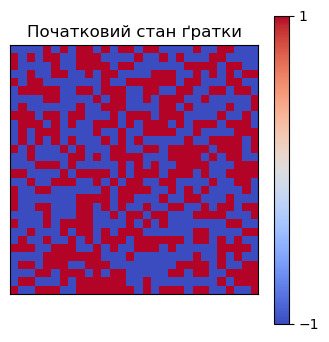

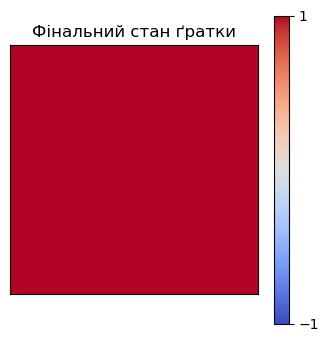

In [21]:
# ---------------------- ЗАПУСК ЕКСПЕРИМЕНТУ ----------------------

N = 30
p_plus_initial = 0.5
max_steps = 1_000_000

init_grid = initialize_voter_model(N, p_plus_initial)
steps, result, grid = simulate_voter_model(init_grid, max_steps)

if steps < max_steps:
    print(f"Консенсус за {steps} кроків.")
    print(f"Кінцевий стан: {result} ({'ЗА' if result == 1 else 'ПРОТИ'}).")
else:
    print(f"Консенсус не досягнуто за {max_steps} кроків.")
    print(f"Поточний середній стан: {np.mean(grid):.3f}.")

# Візуалізація початкового стану
plt.figure(figsize=(4, 4))
plt.title("Початковий стан ґратки")
plt.imshow(init_grid, cmap=plt.cm.coolwarm, vmin=-1, vmax=1)
plt.xticks([])
plt.yticks([])
plt.colorbar(ticks=[-1, 1])
plt.show()

# Візуалізація фінального стану
plt.figure(figsize=(4, 4))
plt.title("Фінальний стан ґратки")
plt.imshow(grid, cmap=plt.cm.coolwarm, vmin=-1, vmax=1)
plt.xticks([])
plt.yticks([])
plt.colorbar(ticks=[-1, 1])
plt.show()


## Модель Шнайда

In [9]:
# ---------------------- МОДЕЛЬ ШНАЙДА ----------------------

def initialize_sznajd(N, p_plus):
    """Ініціалізація решітки значеннями +1 / -1 з ймовірністю p_plus для +1."""
    return np.random.choice([1, -1], size=(N, N), p=[p_plus, 1 - p_plus])

def is_consensus(grid):
    """Чи всі клітинки мають однакове значення."""
    return np.all(grid == grid[0, 0])

def sznajd_model_step(grid):
    N = grid.shape[0]

    # Випадковий спін
    i = np.random.randint(0, N)
    j = np.random.randint(0, N)

    # Випадковий сусід (фон Неймана)
    di, dj = random.choice([(-1, 0), (1, 0), (0, -1), (0, 1)])
    ni = (i + di) % N
    nj = (j + dj) % N

    # Якщо пара згодна – переконує своїх сусідів (околом Мура)
    if grid[i, j] == grid[ni, nj]:
        opinion = grid[i, j]
        moore_neighbors = [(a, b) for a in (-1, 0, 1)
                                   for b in (-1, 0, 1)
                                   if not (a == 0 and b == 0)]
        for ci, cj in [(i, j), (ni, nj)]:
            for a, b in moore_neighbors:
                ti = (ci + a) % N
                tj = (cj + b) % N
                grid[ti, tj] = opinion

    return grid

def simulate_sznajd_model(grid, max_steps):
    grid = copy.deepcopy(grid)
    steps = 0

    while steps < max_steps and not is_consensus(grid):
        sznajd_model_step(grid)
        steps += 1

    final_state = 1 if np.mean(grid) > 0 else -1
    return steps, final_state, grid


--- Модель Шнайда (30x30, p(+1)=0.525) ---
Консенсус досягнуто за 8015 кроків.
Перемогла думка: ЗА (+1).


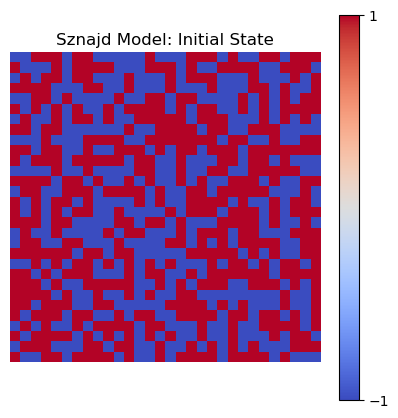

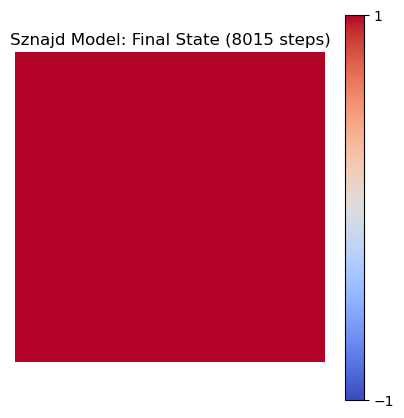

In [10]:
# ---------------------- ЗАПУСК ЕКСПЕРИМЕНТУ ----------------------

N = 30
p_plus_initial = 0.525   # початкова частка +1
max_steps = 200_000

print(f"\n--- Модель Шнайда ({N}x{N}, p(+1)={p_plus_initial}) ---")

init_grid = initialize_sznajd(N, p_plus_initial)
steps, result, final_grid = simulate_sznajd_model(init_grid, max_steps)

if steps < max_steps:
    print(f"Консенсус досягнуто за {steps} кроків.")
    print(f"Перемогла думка: {'ЗА (+1)' if result == 1 else 'ПРОТИ (-1)'}.")
else:
    print(f"Консенсус не досягнуто за {max_steps} кроків.")
    print(f"Середнє значення спінів: {np.mean(final_grid):.4f}")

# Візуалізація початкового стану
plt.figure(figsize=(5, 5))
plt.imshow(init_grid, cmap='coolwarm', vmin=-1, vmax=1)
plt.title(f"Sznajd Model: Initial State")
plt.axis('off')
plt.colorbar(ticks=[-1, 1])
plt.show()

# Візуалізація фінального стану
plt.figure(figsize=(5, 5))
plt.imshow(final_grid, cmap='coolwarm', vmin=-1, vmax=1)
plt.title(f"Sznajd Model: Final State ({steps} steps)")
plt.axis('off')
plt.colorbar(ticks=[-1, 1])
plt.show()

## Модель взаємодії

In [11]:
# ---------------------- МОДЕЛЬ ВІДНОСНОЇ ЗГОДИ ----------------------

def initialize_relative_agreement(N, opinions_max=128):
    # int значення від 1 до opinions_max
    return np.random.randint(1, opinions_max + 1, size=(N, N))

def is_consensus(grid):
    return np.all(grid == grid[0, 0])

def relative_agreement_step(grid, epsilon, m):
    N = grid.shape[0]

    ax, ay = np.random.randint(N, size=2)
    bx, by = np.random.randint(N, size=2)


    o_i = grid[ax, ay]
    o_j = grid[bx, by]

    # дослівно: if (o_i - o_j < e)
    if np.abs(o_i - o_j) < epsilon:
        delta = (m / 2.0) * (o_i - o_j)
        grid[ax, ay] = int(grid[ax, ay] - delta)
        grid[bx, by] = int(grid[bx, by] + delta)

    return grid

def simulate_relative_agreement(grid, epsilon, m, max_steps):
    step = 0
    grid = copy.deepcopy(grid)
    while not is_consensus(grid) and step < max_steps:
        relative_agreement_step(grid, epsilon, m)
        step += 1

    return step, grid

In [12]:
# ---------------------- ЗАПУСК ЕКСПЕРИМЕНТУ ----------------------

N = 50
epsilon = 100     # поріг "екстремістської сили"
m = 0.6           # коефіцієнт спротиву
max_steps = 1_000_000

print(f"\n--- Модель Взаємодії ({N}x{N}, ε={epsilon}, m={m}) ---")

init_grid = initialize_relative_agreement(N)
steps, final_grid = simulate_relative_agreement(init_grid, epsilon, m, max_steps)

final_min = np.min(final_grid)
final_max = np.max(final_grid)
final_spread = final_max - final_min

if is_consensus(final_grid):
    print(f"Повний консенсус досягнуто за {steps} кроків.")
    print(f"Спільна думка: {final_grid[0, 0]}")
else:
    print(f"Симуляцію завершено без повного консенсусу (step = {steps}).")
    print(f"Кінцевий розкид: {final_spread:.2f} (min={final_min:.2f}, max={final_max:.2f})")



--- Модель Взаємодії (50x50, ε=100, m=0.6) ---
Повний консенсус досягнуто за 55888 кроків.
Спільна думка: 52


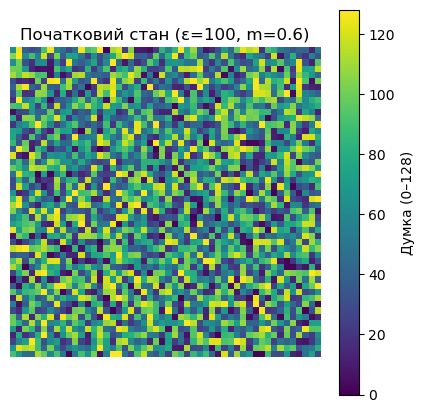

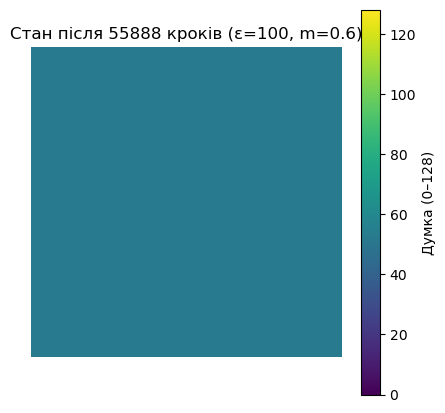

In [13]:
# ---------------------- ВІЗУАЛІЗАЦІЯ ----------------------
plt.figure(figsize=(5, 5))
plt.imshow(init_grid, cmap='viridis', vmin=0, vmax=128)
plt.colorbar(label='Думка (0–128)')
plt.title(f"Початковий стан (ε={epsilon}, m={m})")
plt.axis('off')
plt.show()

# Карта думок
plt.figure(figsize=(5, 5))
plt.imshow(final_grid, cmap='viridis', vmin=0, vmax=128)
plt.colorbar(label='Думка (0–128)')
plt.title(f"Стан після {steps} кроків (ε={epsilon}, m={m})")
plt.axis('off')
plt.show()


# Модель сегрегації населення

### Логіка моделі:
1.  **Поле:** Решітка, де живуть агенти двох типів (наприклад, Сині та Червоні) + порожні клітинки.
2.  **Щастя агента:** Агент задоволений, якщо серед його сусідів певний відсоток (поріг `threshold`) є "своїми" (такого ж кольору).
    *   *Наприклад:* Агент хоче, щоб хоча б 30% сусідів були такими ж, як він.
3.  **Переїзд:** Якщо агент нещасливий, він переїжджає на випадкову **порожню** клітинку.

In [14]:
# Константи станів клітинок
EMPTY = 0
GROUP_A = 1
GROUP_B = 2

In [15]:
def initialize_grid(size, empty_ratio):
    """
    Створює початкову сітку з випадковим розподілом агентів.
    """
    n_cells = size * size
    n_empty = int(n_cells * empty_ratio)
    n_agents = n_cells - n_empty
    n_group_a = n_agents // 2
    n_group_b = n_agents - n_group_a

    population = [EMPTY] * n_empty + [GROUP_A] * n_group_a + [GROUP_B] * n_group_b
    random.shuffle(population)

    return np.array(population).reshape(size, size)

In [16]:
def is_unhappy(grid, x, y, threshold):
    """
    Перевіряє, чи задоволений агент своїм оточенням (окіл Мура).
    """
    agent_type = grid[x, y]
    if agent_type == EMPTY:
        return False

    rows, cols = grid.shape
    same_count = 0
    total_neighbors = 0

    for i in [-1, 0, 1]:
        for j in [-1, 0, 1]:
            if i == 0 and j == 0:
                continue

            nx, ny = x + i, y + j
            if 0 <= nx < rows and 0 <= ny < cols:
                neighbor_type = grid[nx, ny]
                if neighbor_type != EMPTY:
                    total_neighbors += 1
                    if neighbor_type == agent_type:
                        same_count += 1

    if total_neighbors == 0:
        return False

    similarity_ratio = same_count / total_neighbors
    return similarity_ratio < threshold

In [17]:
def run_simulation(grid, threshold, max_iters):
    """
    Запускає процес міграції агентів.
    """
    rows, cols = grid.shape
    history = [grid.copy()]

    for it in range(max_iters):
        unhappy_agents = []
        empty_spots = []

        for r in range(rows):
            for c in range(cols):
                if grid[r, c] == EMPTY:
                    empty_spots.append((r, c))
                elif is_unhappy(grid, r, c, threshold):
                    unhappy_agents.append((r, c))

        if not unhappy_agents:
            print(f"Консенсус досягнуто на ітерації {it}")
            break

        random.shuffle(unhappy_agents)
        random.shuffle(empty_spots)

        while unhappy_agents and empty_spots:
            old_x, old_y = unhappy_agents.pop()
            new_x, new_y = empty_spots.pop()

            grid[new_x, new_y] = grid[old_x, old_y]
            grid[old_x, old_y] = EMPTY

        if it % 10 == 0:
            history.append(grid.copy())

    history.append(grid.copy())
    return history

Консенсус досягнуто на ітерації 15


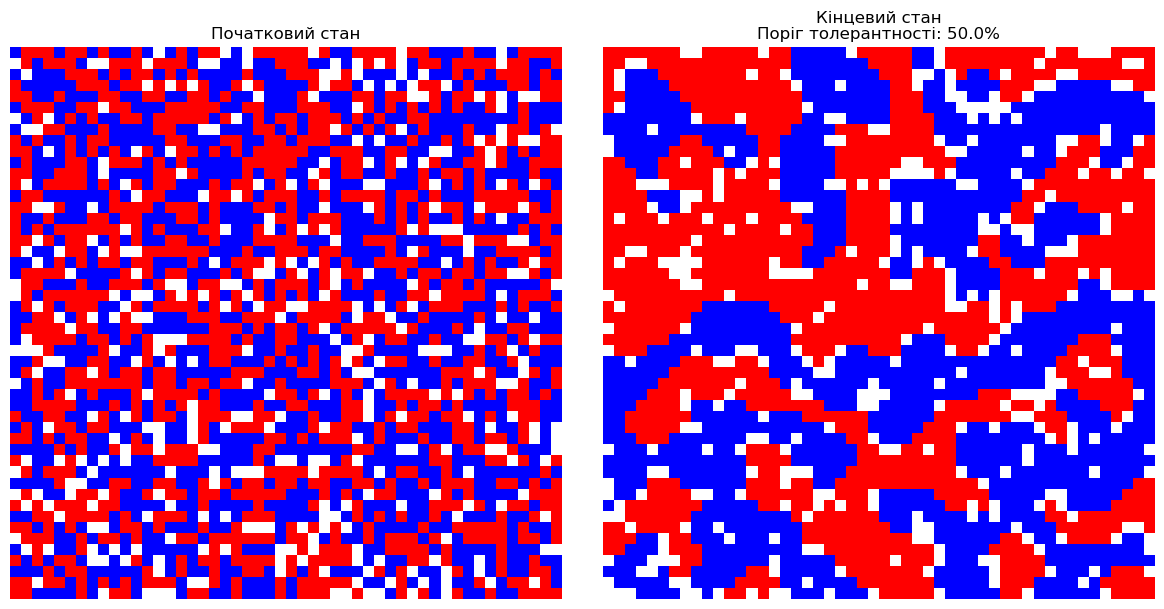

In [18]:
# --- КОНФІГУРАЦІЯ МОДЕЛІ ---
GRID_SIZE = 50                # Розмір сітки (50x50)
EMPTY_RATIO = 0.15            # Відсоток порожніх будинків
SIMILARITY_THRESHOLD = 0.5    # Мінімальна частка "своїх" сусідів
MAX_ITERATIONS = 500          # Максимальна кількість ітерацій
import matplotlib.colors as mcolors

def plot_results(history):
    """
    Малює початковий і фінальний стан моделі.
    """
    cmap = mcolors.ListedColormap(['white', 'blue', 'red'])
    bounds = [0, 0.5, 1.5, 2.5]
    norm = mcolors.BoundaryNorm(bounds, cmap.N)

    fig, axs = plt.subplots(1, 2, figsize=(12, 6))

    axs[0].imshow(history[0], cmap=cmap, norm=norm)
    axs[0].set_title("Початковий стан")
    axs[0].axis('off')

    axs[1].imshow(history[-1], cmap=cmap, norm=norm)
    axs[1].set_title(
        f"Кінцевий стан\nПоріг толерантності: {SIMILARITY_THRESHOLD*100}%"
    )
    axs[1].axis('off')

    plt.tight_layout()
    plt.show()

grid = initialize_grid(GRID_SIZE, EMPTY_RATIO)
history = run_simulation(grid, SIMILARITY_THRESHOLD, MAX_ITERATIONS)
plot_results(history)